# Corporación Favorita Grocery Sales Forecasting
## Data Preparation and Exploratory Data Analysis  


## 1. Introduction

This project is based on a simplified version of the original Kaggle competition *Corporación Favorita Grocery Sales Forecasting*.  
The objective is to analyze and model a daily time series representing unit sales.

The provided dataset contains aggregated daily sales (`unit_sales`) indexed by date.  
No store-level or item-level identifiers are available in the simplified version.  
Therefore, the analysis treats the data as a single aggregated time series.

In addition to the main time series dataset, auxiliary datasets are provided:
- Holidays dataset (including national, regional, and local events)
- Oil price dataset (daily oil price values)
- Stores dataset (store-level metadata)

Since no store identifier is present in the main time series, store-level information cannot be directly integrated into the analysis.  
External variables such as holidays and oil prices will be evaluated as potential explanatory factors.

---


This notebook focuses on:

1. Data cleaning and preprocessing  
2. Ensuring temporal consistency (daily frequency, no duplicates, no missing values)  
3. Exploring the statistical properties of the time series  
4. Preparing a clean dataset for subsequent forecasting models  

The final output of this notebook will be a cleaned and structured time series dataset ready for modeling.


**Author**: Maria Petralia   
**Project**: Favorita Sales Forecasting - Time Series  
**Context**: MasterSchool - Data Science Program  
**Date**: Mar 2026

## 2. Libraries and Setup

In [73]:

# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from datetime import date

In [74]:
from pathlib import Path

# Notebook is in notebooks
BASE_DIR = Path().resolve().parent
DATA_PATH  = BASE_DIR / "data"

In [75]:
# Import the os package and list the files in MyDrive
import os
print(os.listdir(DATA_PATH))

['timeseries.csv', '__init__.py', 'results_statistical.csv', 'holidays.csv', 'data_utils.py', 'oil.csv', 'stores.csv']


In [76]:
# Holidays
df_holidays = pd.read_csv(DATA_PATH / "holidays.csv")
display(df_holidays.head())

,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [77]:
df_holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   locale       350 non-null    object
 2   locale_name  350 non-null    object
 3   description  350 non-null    object
dtypes: object(4)
memory usage: 11.1+ KB


**Note**: The `date` column is loaded as an object type and requires conversion to `datetime` before it can be used for time-based filtering and feature creation.

In [78]:
# Oil
df_oil = pd.read_csv(DATA_PATH / "oil.csv")
display(df_oil.head())

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [79]:
df_oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


**Note**: The dataset contains daily WTI oil prices (`dcoilwtico`).  
The `date` column is currently stored as object type and requires conversion to `datetime`.  
Missing values are present and will be examined during the data cleaning phase.



In [80]:
# Stores
df_stores = pd.read_csv(DATA_PATH / "stores.csv")
display(df_stores.head())

,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


In [81]:
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   region     54 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.4+ KB


**Note**: The dataset contains metadata for 54 individual stores, including store number, city, and region.  
No missing values are present.  
The dataset does not include sales information and serves as contextual metadata.

In [82]:
# Timeseries
df_timeseries = pd.read_csv(DATA_PATH / "timeseries.csv")
display(df_timeseries.head())

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


In [83]:
df_timeseries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        452 non-null    object 
 1   unit_sales  452 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.2+ KB


**Note**: The dataset contains 452 daily observations of aggregated `unit_sales`.  
The `date` column is currently stored as an object and will be converted to datetime format in the data cleaning phase.  

No missing values are present in the raw file.

## 3. Data Cleaning

**Data Integrity and Preprocessing**

The following steps ensure temporal consistency, data validity, and structural alignment across all datasets before exploratory analysis.

##### Data Type Conversion

In [84]:
# Convert the columns date (object) in datetime
# Using errors="coerce" ensures that invalid parsing results in NaT
df_holidays["date"] = pd.to_datetime(df_holidays["date"], errors="coerce")
df_oil["date"] = pd.to_datetime(df_oil["date"], errors="coerce")
df_timeseries["date"] = pd.to_datetime(df_timeseries["date"], errors="coerce")

# Verify successful conversion and check for parsing errors
print("Holidays:", df_holidays["date"].dtype, "| NaT:", df_holidays["date"].isna().sum())
print("Oil:", df_oil["date"].dtype, "| NaT:", df_oil["date"].isna().sum())
print("Timeseries:", df_timeseries["date"].dtype, "| NaT:", df_timeseries["date"].isna().sum())


Holidays: datetime64[ns] | NaT: 0
Oil: datetime64[ns] | NaT: 0
Timeseries: datetime64[ns] | NaT: 0


##### Timeseries

In [85]:
# Order timeseries dataset by dates
df_timeseries = df_timeseries.sort_values("date")

# Set date as Index
df_timeseries = df_timeseries.set_index("date")

# Quick check
print(df_timeseries.head())
print("\nIndex type:", type(df_timeseries.index))


            unit_sales
date                  
2013-01-02       582.0
2013-01-03       310.0
2013-01-04       338.0
2013-01-05       654.0
2013-01-06       979.0

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [86]:
df_timeseries.head()

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0


**Note**: The time series starts on **2013-01-02**.  
The date **2013-01-01** is not present in the provided dataset, so no assumptions can be made about sales on that day.  
All subsequent steps treat **2013-01-02** as the first observed point in the series.

In [87]:

# Check duplicates
print("Duplicate dates:", df_timeseries.index.duplicated().sum())

# Enforce daily frequency on the main dataframe
df_timeseries = df_timeseries.asfreq("D")

# Check missing after asfreq
print("Missing dates:", df_timeseries["unit_sales"].isna().sum())


Duplicate dates: 0
Missing dates: 2


**Note**: No duplicate dates are present.

Converting to daily frequency ensures temporal continuity. After setting the index to a daily calendar using asfreq("D"), pandas builds the complete daily range between the first and last date, which contains 454 days.  
This reveals 2 missing dates.

In [88]:
df_timeseries[df_timeseries["unit_sales"].isna()]


,unit_sales
date,
2013-12-25,NaN
2014-01-01,NaN


In [89]:
# Verify whether missing dates correspond to holidays
missing_dates = df_timeseries[df_timeseries["unit_sales"].isna()].index

df_holidays[df_holidays["date"].isin(missing_dates)]

,date,locale,locale_name,description
89,2013-12-25,National,Ecuador,Navidad
92,2014-01-01,National,Ecuador,Primer dia del ano


**Note**: Both missing dates (2013-12-25 and 2014-01-01) correspond to National holidays in the holidays dataset.

Exploratory analysis (see Holiday Analysis section) indicates that holiday sales levels vary depending on the weekday but are not structurally equal to zero.

Based on this empirical evidence, missing values are imputed using the mean sales level observed on Wednesday national holidays within the training period (2013 only).

This approach preserves the weekly structure of the series and avoids introducing artificial outliers (forcing sales to zero) or applying forward filling.

In [90]:
# Identify national holidays in relevant period
df_national = df_holidays[
    (df_holidays["locale"] == "National") &
    (df_holidays["date"] >= "2013-01-01") &
    (df_holidays["date"] <= "2013-12-31")   # train only
]

# Compute empirical mean for Wednesday national holidays (train only)
wed_nat_mean = df_timeseries.loc[
    (df_timeseries.index.isin(df_national["date"])) &
    (df_timeseries.index.day_name() == "Wednesday"),
    "unit_sales"
].mean()

# Impute missing values
df_timeseries.loc["2013-12-25", "unit_sales"] = wed_nat_mean
df_timeseries.loc["2014-01-01", "unit_sales"] = wed_nat_mean

In [91]:
df_timeseries.shape

(454, 1)

**Note**: After imputing those two values, the final time series contains 454 daily observations.

In [92]:
# Statistical check
df_timeseries.describe()

,unit_sales
count,454.000000
mean,480.852423
std,170.847266
min,4.000000
25%,358.500000
50%,448.000000
75%,582.750000
max,1203.000000


**Note**: After enforcing daily frequency and imputing two missing holiday observations, the final series contains 454 daily observations.

The distribution of `unit_sales` shows high variability (max = 1203) and a very small minimum (min = 4).  
This indicates at least one unusually low-sales day in the aggregated series.

In [93]:
# Check the 5 min unit-sales
df_timeseries["unit_sales"].sort_values().head(5)

date
2013-01-17      4.0
2013-01-18     60.0
2014-03-20    139.0
2013-02-22    186.0
2013-11-21    199.0
Name: unit_sales, dtype: float64

In [94]:
# Verify if the abnormal sales drop on 2013-01-17
# is associated with any National, Regional, or Local holiday
# by inspecting the holiday dataset around that date
df_holidays[
    (df_holidays["date"] >= "2013-01-16") &
    (df_holidays["date"] <= "2013-01-19")
]

,date,locale,locale_name,description


**Note**: The lowest observed value (4 units) occurs on 2013-01-17, followed by another unusually low value (60 units) on 2013-01-18.

None of the lowest-sales dates correspond to National, Regional, or Local holidays in the provided calendar dataset.  

Given the absence of any calendar-related explanation and the aggregated nature of the series, these observations are treated as isolated outliers rather than evidence of a structural or systemic event. No corrective action is taken, since removing or imputing would require assumptions not supported by the provided data.

##### Holidays

In [95]:
# Quick overview
df_holidays.head()

,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [96]:
# Check exact duplicate row
df_holidays.duplicated().sum()

np.int64(0)

In [97]:
# Multiple holidays can share the same date, check duplicates by date
df_holidays["date"].duplicated().sum()

np.int64(38)

In [98]:
# Holiday categories
df_holidays["locale"].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

**Note**: National holidays represent country-wide events, while Regional and Local holidays apply to specific geographic areas.


In [99]:
# Dataset richness to understand granularity
print("Unique locale_name:", df_holidays["locale_name"].nunique())
print("Unique holiday descriptions:", df_holidays["description"].nunique())
print("Unique holiday dates overall:", df_holidays["date"].nunique())

Unique locale_name: 24
Unique holiday descriptions: 103
Unique holiday dates overall: 312


**Note**: The dataset contains holidays at multiple geographic levels (National/Regional/Local), with several distinct locations and descriptions. Since the main time series has no store/location key, no holiday category is excluded at this stage.

##### Oil

In [100]:
# Check missing values
df_oil.isna().sum()

date           0
dcoilwtico    43
dtype: int64

**Note**: The oil price dataset contains 43 missing values in the `dcoilwtico` column.  
No missing values are present in the date column.

The proportion of missing values is small relative to the full series.

Further investigation is required to determine whether the missing values follow a specific pattern (weekends or market closures).


In [101]:
# Check date range
print("Oil date range:", df_oil["date"].min(), "-", df_oil["date"].max())
print("Sales date range:", df_timeseries.index.min(), "-", df_timeseries.index.max())

Oil date range: 2013-01-01 00:00:00 - 2017-08-31 00:00:00
Sales date range: 2013-01-02 00:00:00 - 2014-03-31 00:00:00


**Note**: The oil price dataset fully covers the time span of the sales data (2013-01-02 to 2014-03-31).    
Therefore, there are no coverage issues, and the oil series can be safely aligned with the sales time series for the entire analysis period.


In [102]:
# Inspect missing dates
df_oil[df_oil["dcoilwtico"].isna()]

,date,dcoilwtico
0,2013-01-01,NaN
14,2013-01-21,NaN
34,2013-02-18,NaN
63,2013-03-29,NaN
104,2013-05-27,NaN
132,2013-07-04,NaN
174,2013-09-02,NaN
237,2013-11-28,NaN
256,2013-12-25,NaN
261,2014-01-01,NaN


**Note**:  The missing values in the oil price dataset correspond to specific recurring dates, which align with U.S. market holidays (Independence Day, Thanksgiving, Christmas, New Year's Day).

Since the WTI oil price is not quoted on market closure days, these missing values do not represent data errors but rather non-trading days.

To preserve economic consistency, missing values will later be handled using forward filling (last observation carried forward), which is standard practice for financial time series.


In [103]:
# Check- Count missing oil values within the sales period
# Define sales period
sales_start = df_timeseries.index.min()
sales_end = df_timeseries.index.max()

# Filter oil data within sales period
oil_sales_period = df_oil[(df_oil["date"]>= sales_start)&(df_oil["date"]<= sales_end)]

# Count missing
oil_sales_period["dcoilwtico"].isna().sum()


np.int64(11)

**Note**: Within the sales period (2013-01-02 to 2014-03-31), 11 oil price observations are missing.

These dates correspond to market closure days (major U.S. holidays).  
The proportion of missing values is small and does not represent a structural issue.

Missing values will be handled using forward filling (last observation carried forward).


In [104]:
# Align oil dataset to daily frequency
df_oil = df_oil.set_index("date")

# Reindex to daily frequency
df_oil = df_oil.asfreq("D")

# Forward fill missing values (market closure days)
# This assumes price continuity across non-trading days
df_oil["dcoilwtico"] = df_oil["dcoilwtico"].ffill()

# Final check
df_oil.isna().sum()


dcoilwtico    1
dtype: int64

In [105]:
# Check the only one missing value
df_oil[df_oil["dcoilwtico"].isna()]

,dcoilwtico
date,
2013-01-01,NaN


**Note**: After forward filling, one missing value remains at the beginning of the oil series (2013-01-01).    
This occurs because forward filling requires a previous observation.  

Since the sales time series starts on 2013-01-02, this missing value does not affect the analysis and can be safely ignored.  


##### Store

In [106]:
df_stores.head()

,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


In [107]:
print("Duplicate store rows:", df_stores.duplicated().sum())
print("Unique stores:", df_stores["store_nbr"].nunique())
print("Regions:", df_stores["region"].nunique())

Duplicate store rows: 0
Unique stores: 54
Regions: 16


**Stores Dataset Integrity Check**

The dataset contains 54 unique stores distributed across 16 regions.  
No duplicate rows are present.

However, the sales time series does not include a store identifier (`store_nbr`).  
As a result, store-level metadata cannot be directly linked to the aggregated daily sales data.

The stores dataset is therefore retained for exploratory purposes only and is not incorporated into the final modeling dataset.

## 4. Exploratory Data Analysis

###### Timeserie Analysis

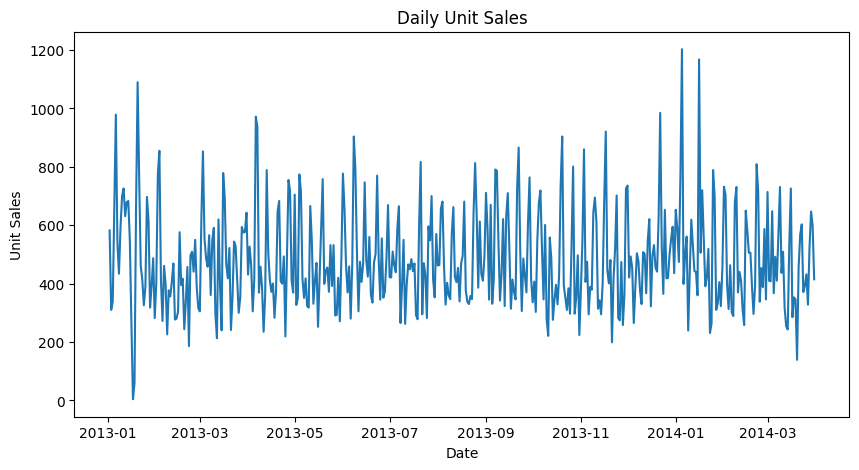

In [108]:
# Plot sales time series
plt.figure(figsize = (10,5))
plt.plot(df_timeseries.index, df_timeseries["unit_sales"])
plt.title("Daily Unit Sales")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.show()

**Note**:
- No strong upward or downward long-term trend is immediately visible.
- The series fluctuates around a relatively stable average level (approximately 400-500 units).
- Several sharp spikes are present, with peak values exceeding 1000 units.
- At least one observation is close to zero. This may reflect an exceptional low-sales day, a closure, or a data gap; the dataset does not provide enough information to confirm the cause.
- A potential weekly seasonal pattern may be present, although it is not clearly distinguishable from visual inspection alone.

Overall, the series appears to have a relatively stable level with high variability and possible seasonal effects.

An additive model is used since the seasonal amplitude appears relatively stable over time.   
The period is set to 7 to capture weekly seasonality.

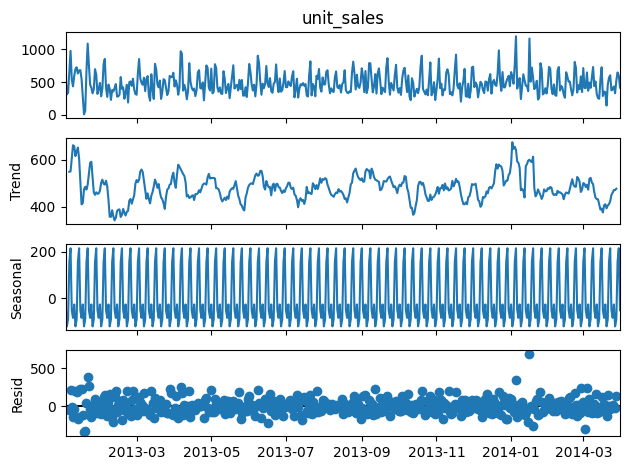

In [109]:
# Seasonal decomposition
decomposition = seasonal_decompose(df_timeseries["unit_sales"], model="additive", period = 7)
decomposition.plot()
plt.show()

**Note**:  
**Trend**: Moderate fluctuations are observed over time, with no persistent upward or downward movement.  
The overall sales level remains relatively stable.

**Seasonality**: A strong and stable weekly pattern is evident, with an amplitude of approximately 100 units.   
This confirms systematic differences across weekdays.

**Residuals**: Residuals are centered around zero but exhibit substantial variability and occasional outliers, suggesting additional unexplained factors.

In [110]:
# Augmented Dickey-Fuller Test
# Null hypothesis: the series is non-stationary
adf_result = adfuller(df_timeseries["unit_sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -4.910871220577149
p-value: 3.321436795248176e-05
Critical Values:
   1%: -3.4454725477848998
   5%: -2.8682072297316794
   10%: -2.570321396485665


**Note**: The **ADF statistic** (-5.09) is lower than the 5% critical value (-2.87), and the p-value is significantly below 0.05.

Therefore, the null hypothesis of non-stationarity is rejected,
indicating that the series is stationary in levels.

This suggests that no first-order differencing (d = 0) may be required
for ARIMA modeling.


<Figure size 1000x500 with 0 Axes>

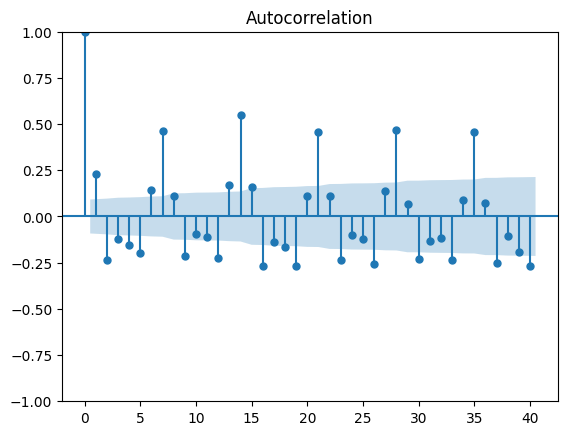

In [111]:
# Autocorrelation Function (ACF)
plt.figure(figsize=(10,5))
plot_acf(df_timeseries["unit_sales"], lags=40)
plt.show()


**Note**: The ACF plot shows a moderate positive autocorrelation at lag 1, indicating short-term persistence in daily sales.

Several negative autocorrelations are observed at intermediate lags, suggesting short-term oscillatory behavior.

Most notably, strong and recurring positive spikes appear at lags 7, 14, 21, and subsequent multiples of 7.  
This pattern clearly indicates the presence of weekly seasonality in the data.

Overall, the series exhibits both short-term dependence and a strong weekly seasonal structure.


<Figure size 1000x500 with 0 Axes>

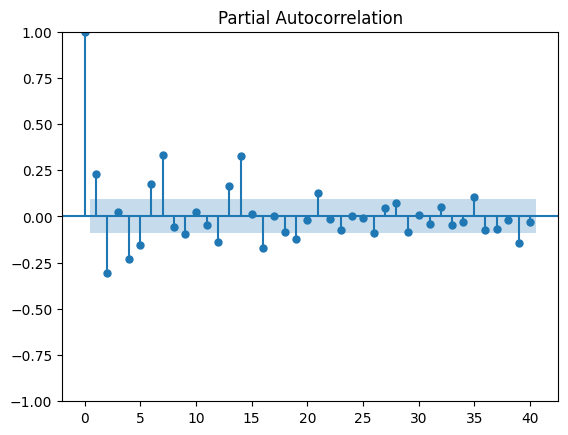

In [112]:
# Partial Autocorrelation Function (PACF)
plt.figure(figsize=(10,5))
plot_pacf(df_timeseries["unit_sales"], lags=40, method="ywm")
plt.show()

**Note**: The PACF plot shows significant partial autocorrelation at lag 1 and lag 2, indicating short-term dependence in the series.

Beyond the first few lags, most values fall within the confidence interval, suggesting that the strongest direct effects occur at short lags.

A noticeable spike is also present at lag 7, reinforcing the evidence of weekly seasonality observed in the ACF plot.

These results confirm that the time series exhibits structured temporal dependence rather than pure randomness.


In [113]:
# Create weekday features
# day_of_week: numerical encoding (0=Monday, 6=Sunday)
# day_name: categorical label for interpretation
dow_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df_timeseries["day_of_week"] = df_timeseries.index.dayofweek
df_timeseries["day_name"] = df_timeseries.index.day_name()

# Average sales by day of week
dow_mean = df_timeseries.groupby("day_name")["unit_sales"].mean()
dow_mean = dow_mean.reindex(dow_order)
dow_mean


day_name
Monday       429.969231
Tuesday      397.718750
Wednesday    457.184615
Thursday     359.661538
Friday       389.230769
Saturday     636.830769
Sunday       694.092308
Name: unit_sales, dtype: float64

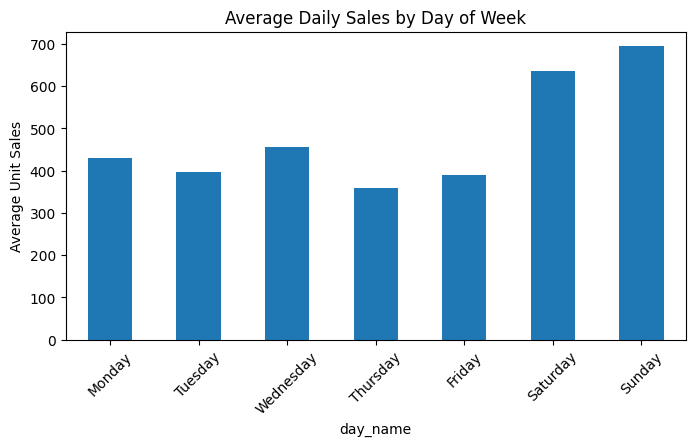

In [114]:
# Plot average sales by day
plt.figure(figsize=(8,4))
dow_mean.plot(kind="bar")
plt.title("Average Daily Sales by Day of Week")
plt.ylabel("Average Unit Sales")
plt.xticks(rotation=45)
plt.show()


**Note**: Average sales vary substantially across days of the week.

Weekend days (Saturday and Sunday) exhibit significantly higher average sales,
with Sunday reaching the highest average level.

In contrast, Thursday and Friday show the lowest average sales.

The difference between the highest and lowest days exceeds 300 units,
indicating a strong and economically meaningful weekly pattern.

This finding confirms the presence of a pronounced weekly seasonality, consistent with the results from the decomposition and autocorrelation analysis.

<Figure size 1000x500 with 0 Axes>

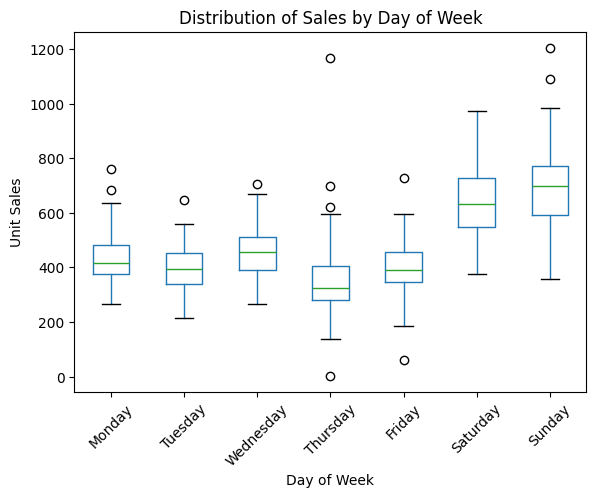

In [115]:
# Boxplot by day of week
plt.figure(figsize=(10,5))

df_timeseries.boxplot(
    column="unit_sales",
    by=pd.Categorical(df_timeseries["day_name"], categories=dow_order, ordered=True),
    grid=False
)

plt.title("Distribution of Sales by Day of Week")
plt.suptitle("")
plt.xlabel("Day of Week")
plt.ylabel("Unit Sales")
plt.xticks(rotation=45)
plt.show()


**Note**: The boxplot confirms substantial differences in both central tendency and variability across days of the week.

Weekend days (Saturday and Sunday) not only exhibit higher median sales but also greater dispersion, as indicated by wider interquartile ranges and longer whiskers.

Sunday shows the highest median and the largest variability, with several extreme high-value outliers.

In contrast, weekdays, particularly Thursday, display lower median sales and relatively tighter distributions.

These results further confirm a strong and economically meaningful weekly pattern in the sales data.


###### Holiday Analysis

locale,Local,National,Regional
month,,,
1,0,3,0
2,0,2,0
3,2,2,0
4,3,1,1
5,1,4,0
6,2,0,1
7,4,0,0
8,3,1,0
9,1,0,0


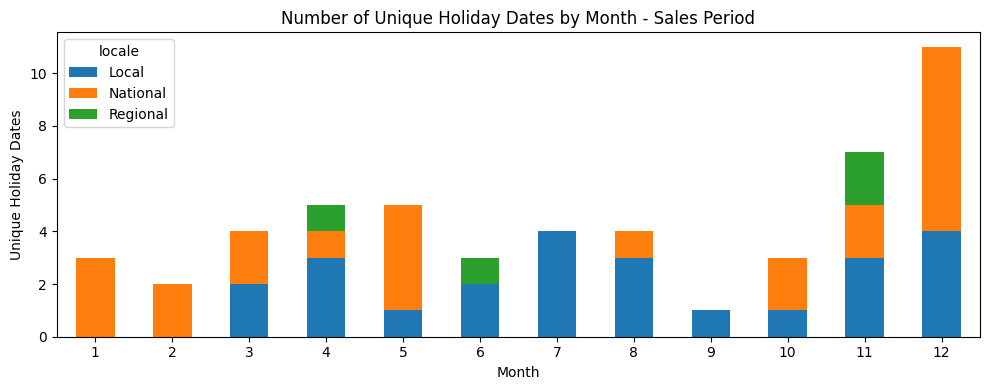

In [116]:
# Holidays per month and locale
# Restrict holidays to the sales period
sales_start = df_timeseries.index.min()
sales_end = df_timeseries.index.max()

hol_period = df_holidays[
    (df_holidays["date"] >= sales_start) &
    (df_holidays["date"] <= sales_end)
].copy()

# Extract month
hol_period["month"] = hol_period["date"].dt.month

# Count UNIQUE holiday dates per month and locale
hol_month = (
    hol_period
    .groupby(["month", "locale"])["date"]
    .nunique()
    .unstack(fill_value=0)
    .sort_index()
)

display(hol_month)

hol_month.plot(kind="bar", stacked=True, figsize=(10,4))
plt.title("Number of Unique Holiday Dates by Month - Sales Period")
plt.xlabel("Month")
plt.ylabel("Unique Holiday Dates")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Note**: The chart reports the number of **unique holiday dates** per month within the sales period (2013-2014).

National holidays occur throughout the year, with a noticeable concentration in December.  
Local holidays are more evenly distributed across months, while Regional holidays are relatively infrequent and limited to a few specific months.

Given the aggregated nature of the sales series and the absence of geographic identifiers, all holiday categories are retained for subsequent analysis.

In [117]:
print("Unique holiday dates in sales period:", hol_period["date"].nunique())

Unique holiday dates in sales period: 49


**Note**: The holidays dataset aligns with the sales period and contains 49 unique holiday dates within the observed time window.

In [118]:
# Create generic holiday flag (any holiday type)
holiday_dates = hol_period["date"].unique()
df_timeseries["is_holiday"] = df_timeseries.index.isin(holiday_dates).astype(int)

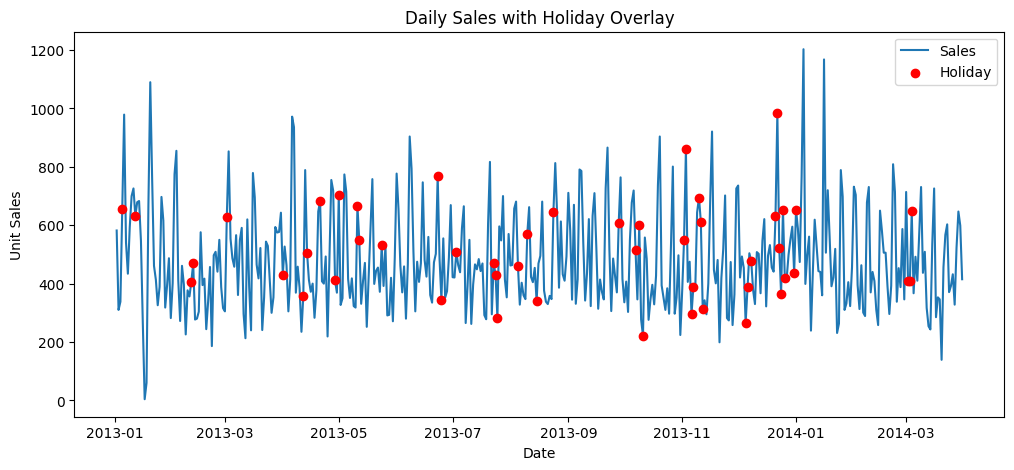

In [119]:
# Plot sales with holiday markers
plt.figure(figsize=(12,5))

# Line plot
plt.plot(df_timeseries.index, df_timeseries["unit_sales"], label="Sales")

# Highlight holidays
holiday_sales = df_timeseries[df_timeseries["is_holiday"] == 1]

plt.scatter(
    holiday_sales.index,
    holiday_sales["unit_sales"],
    color="red",
    label="Holiday",
    zorder=3
)

plt.title("Daily Sales with Holiday Overlay")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()


In [120]:
df_timeseries.groupby("is_holiday")["unit_sales"].mean()

is_holiday
0    476.390123
1    517.734694
Name: unit_sales, dtype: float64

**Note**: The scatter overlay suggests that holidays are not systematically associated with sales drops.
Holiday observations are distributed across the full range of sales values, including both moderate and high-demand days.

Average sales on holidays (517.73) exceed non-holiday days (476.39), indicating that holidays do not correspond to store closures in this aggregated series.

This preliminary evidence suggests that the holiday effect is heterogeneous and likely interacts with the day of the week rather than producing a uniform sales reduction.

In [121]:

# Create separate binary indicators for holiday categories
national_dates = hol_period[hol_period["locale"] == "National"]["date"].unique()
regional_dates = hol_period[hol_period["locale"] == "Regional"]["date"].unique()
local_dates    = hol_period[hol_period["locale"] == "Local"]["date"].unique()

df_timeseries["is_national"] = df_timeseries.index.isin(national_dates).astype(int)
df_timeseries["is_regional"] = df_timeseries.index.isin(regional_dates).astype(int)
df_timeseries["is_local"] = df_timeseries.index.isin(local_dates).astype(int)


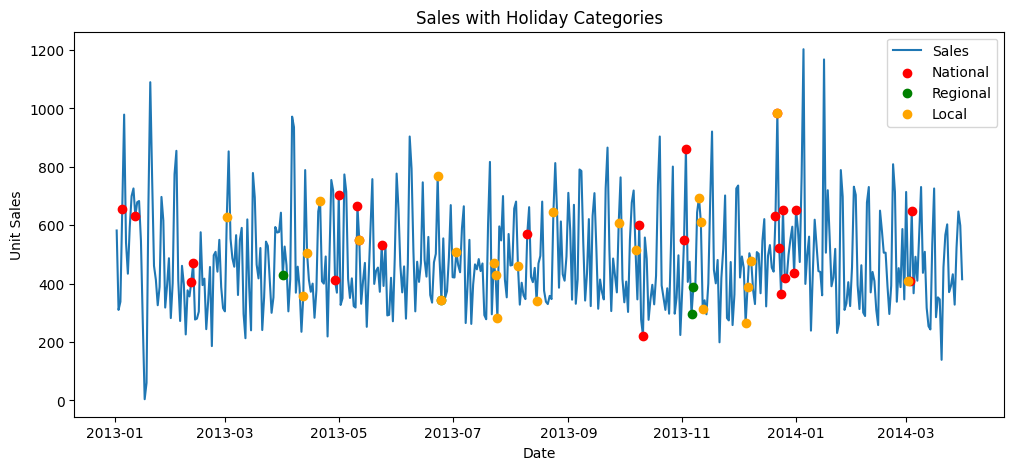

In [122]:
# Plot with holiday categories
plt.figure(figsize=(12,5))

plt.plot(df_timeseries.index, df_timeseries["unit_sales"], label="Sales")

# national holidays
plt.scatter(
    df_timeseries[df_timeseries["is_national"] == 1].index,
    df_timeseries[df_timeseries["is_national"] == 1]["unit_sales"],
    color="red", label="National", zorder=3
)

# regional holidays
plt.scatter(
    df_timeseries[df_timeseries["is_regional"] == 1].index,
    df_timeseries[df_timeseries["is_regional"] == 1]["unit_sales"],
    color="green", label="Regional", zorder=3
)

# local holidays
plt.scatter(
    df_timeseries[df_timeseries["is_local"] == 1].index,
    df_timeseries[df_timeseries["is_local"] == 1]["unit_sales"],
    color="orange", label="Local", zorder=3
)

plt.title("Sales with Holiday Categories")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()


**Note**: The distribution of sales values across National, Regional, and Local holidays does not reveal a uniform pattern.

Some holiday dates are associated with lower sales levels, while others coincide with pronounced sales peaks.
This heterogeneity suggests that holidays do not exert a consistent directional effect on the aggregated series.

No general rule can be inferred from the visual inspection alone.
Holiday impact appears context-dependent and likely interacts with other factors, such as the day of the week.

In [123]:
# Print the mean for holiday and not holiday unit-sales
print("National:", df_timeseries[df_timeseries["is_national"] == 1]["unit_sales"].mean())
print("Regional:", df_timeseries[df_timeseries["is_regional"] == 1]["unit_sales"].mean())
print("Local:", df_timeseries[df_timeseries["is_local"] == 1]["unit_sales"].mean())
print("Non-holiday:", df_timeseries[df_timeseries["is_holiday"] == 0]["unit_sales"].mean())

National: 564.2916666666666
Regional: 365.0
Local: 510.1666666666667
Non-holiday: 476.39012345679015


**Note**: National and Local holidays are associated with higher average sales compared to regular days, while Regional holidays exhibit lower average sales.

This confirms that the holiday effect is heterogeneous and category-dependent.
No single directional effect can be generalized across all holiday types.

The impact of holidays therefore appears context-specific and likely interacts with weekly demand patterns.

In [124]:
# Holiday effect by day of week
holiday_dow = (
    df_timeseries
    .groupby(["day_name", "is_holiday"])["unit_sales"]
    .mean()
    .unstack()
)
holiday_dow = holiday_dow.reindex(dow_order)
holiday_dow


is_holiday,0,1
day_name,,
Monday,424.210526,471.000000
Tuesday,393.105263,435.285714
Wednesday,446.017241,549.714286
Thursday,361.416667,338.600000
Friday,390.180328,374.750000
Saturday,639.535714,620.000000
Sunday,699.678571,659.333333


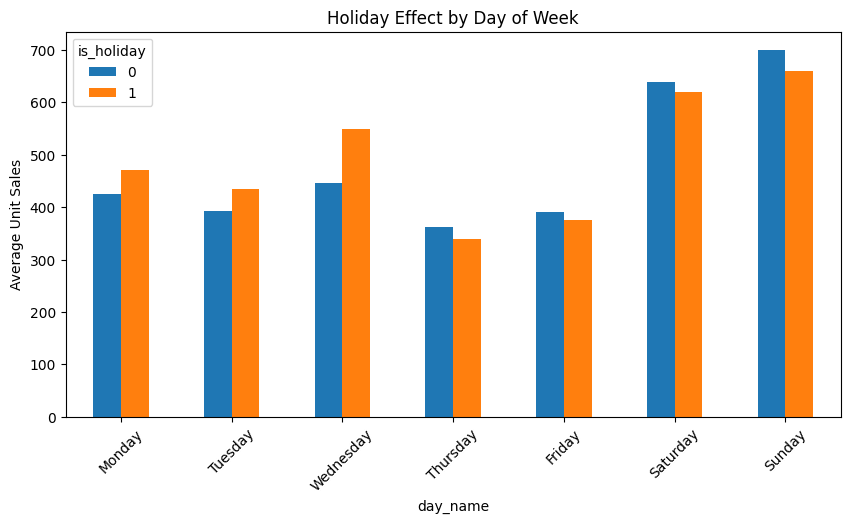

In [125]:
holiday_dow.plot(kind="bar", figsize=(10,5))
plt.title("Holiday Effect by Day of Week")
plt.ylabel("Average Unit Sales")
plt.xticks(rotation=45)
plt.show()


**Note**: When controlling for the day of the week, holiday effects are not uniform.

Differences between holidays and non-holidays vary across weekdays and weekends.  
For example, mid-week holidays (especially Wednesday) are associated with higher sales, while weekend holidays tend to show slightly lower sales compared to regular weekends.

This suggests that calendar effects interact with weekly seasonality rather than acting as a constant additive shift.

For this reason, interaction features (`holiday_weekday`, `holiday_weekend`) are introduced to allow models to learn different holiday impacts depending on whether the holiday falls on a weekday or weekend.

In [126]:
# Create weekend indicator
df_timeseries["is_weekend"] = (
    df_timeseries["day_of_week"].isin([5, 6])
).astype(int)

# Create interaction features
df_timeseries["holiday_weekday"] = (
    df_timeseries["is_holiday"] * (1 - df_timeseries["is_weekend"])
)

df_timeseries["holiday_weekend"] = (
    df_timeseries["is_holiday"] * df_timeseries["is_weekend"]
)

**Note**: Given the heterogeneous holiday effect observed in the previous analysis, interaction features between holidays and weekends are introduced.  
These variables allow subsequent models to differentiate between holiday effects occurring on weekdays and those occurring on weekends.

###### Oil Analysis

In [127]:
# Merge oil prices with sales series using date index
# Left join ensures all sales dates are preserved
df_merged = df_timeseries.merge(df_oil[["dcoilwtico"]], left_index=True, right_index=True, how="left")

df_merged.head()


,unit_sales,day_of_week,day_name,is_holiday,is_national,is_regional,is_local,is_weekend,holiday_weekday,holiday_weekend,dcoilwtico
date,,,,,,,,,,,
2013-01-02,582.0,2,Wednesday,0,0,0,0,0,0,0,93.14
2013-01-03,310.0,3,Thursday,0,0,0,0,0,0,0,92.97
2013-01-04,338.0,4,Friday,0,0,0,0,0,0,0,93.12
2013-01-05,654.0,5,Saturday,1,1,0,0,1,0,1,93.12
2013-01-06,979.0,6,Sunday,0,0,0,0,1,0,0,93.12


In [128]:
df_oil.index.to_series().diff().value_counts().head()

date
1 days    1703
Name: count, dtype: int64

**Note**: No gap between dates

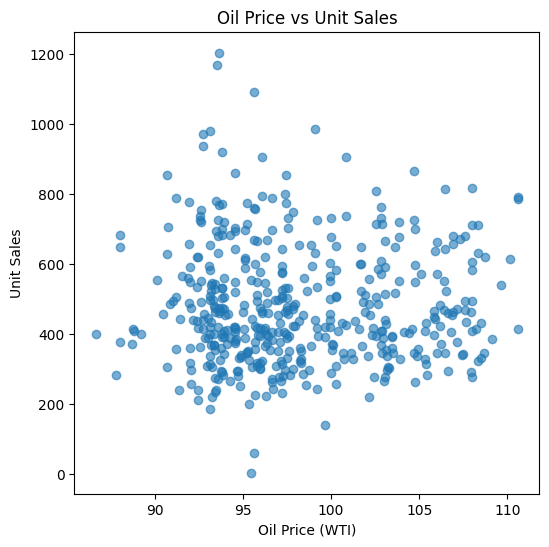

In [129]:
# Scatter: Oil price vs Sales
plt.figure(figsize=(6,6))
plt.scatter(df_merged["dcoilwtico"], df_merged["unit_sales"], alpha=0.6)
plt.xlabel("Oil Price (WTI)")
plt.ylabel("Unit Sales")
plt.title("Oil Price vs Unit Sales")
plt.show()


**Note**: The scatterplot between oil prices and daily unit sales does not reveal a clear linear relationship.

Sales values appear widely dispersed across all oil price levels,
with no evident upward or downward trend.

This suggests that oil prices do not exhibit a strong contemporaneous relationship with daily grocery sales in the observed period.


In [130]:
# Compute lagged correlations (0–14 days)
# Tests whether oil price changes precede sales movements
lag_corr = {}
for lag in range(0, 15):
    lag_corr[lag] = df_merged["unit_sales"].corr(df_merged["dcoilwtico"].shift(lag))

pd.Series(lag_corr, name="corr").to_frame()


,corr
0,0.004826
1,0.013457
2,0.002215
3,-0.005467
4,-0.009305
5,-0.004222
6,0.004222
7,0.010251
8,0.009980
9,0.011435


**Note**: Correlation values between oil prices and daily unit sales (lags 0-14) remain extremely close to zero.

No meaningful linear relationship is observed, either contemporaneously or with short-term lags.

Oil price fluctuations do not appear to exert a measurable short-term influence on daily grocery sales during the observed period.


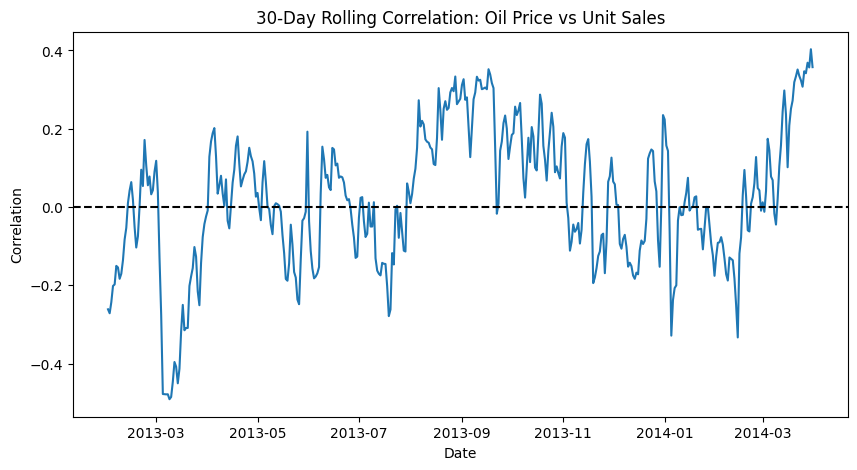

In [131]:
# Rolling correlation between oil prices and sales
# Window size: 30 days
rolling_corr = (
    df_merged["unit_sales"]
    .rolling(window=30)
    .corr(df_merged["dcoilwtico"])
)

plt.figure(figsize=(10,5))
plt.plot(rolling_corr)
plt.axhline(0, color="black", linestyle="--")
plt.title("30-Day Rolling Correlation: Oil Price vs Unit Sales")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.show()


**Note**: The 30-day rolling correlation fluctuates substantially over time,
alternating between moderately positive and moderately negative values.

However, no persistent or stable relationship is observed.  
Periods of positive correlation are followed by reversals, and no long-term directional pattern emerges.

This indicates that any short-term association between oil prices and sales is unstable and likely driven by transient factors rather than a structural relationship.


**Conclusion**: Oil prices are not included as features in the final dataset, as no stable relationship with unit sales is observed in this simplified setting.

###### **Store Analysis**

The sales dataset contains a single aggregated daily time series (`unit_sales`) and does not include any store identifier.  
Because of this, the `stores` table cannot be merged directly into the modeling dataset.

A short sanity check is performed to assess whether the series could plausibly reflect one specific geographic area.  
The working hypothesis is that the time series might represent a single (unknown) store, meaning that sales could be influenced by a city-specific holiday calendar.


To test this hypothesis, a city-specific holiday calendar is constructed for each store location.  
Under a single-store assumption, a store would be affected by:

- National holidays  
- Regional holidays matching the store's region  
- Local holidays matching the store's city  

For each city, average sales are compared between holiday dates (according to the city-specific calendar) and non-holiday dates.

If the time series truly represented a specific store, one city would be expected to exhibit a clearer or more structurally distinct holiday pattern than others.

In [132]:
# Function: compute_city_holiday_effect
# Purpose: Evaluate whether the sales series aligns with the holiday
# calendar of a specific city (as if it represented a single store).

def compute_city_holiday_effect(city_row):
  # Extract city and region information
  city = city_row["city"]
  region = city_row["region"]

  # Construct a city-specific holiday calendar
  # A store located in this city would be affected by:
  # - All National holidays
  # - Regional holidays matching the store's region
  # - Local holidays matching the store's city
  city_holidays = df_holidays[
      (df_holidays["locale"] == "National") |
      ((df_holidays["locale"] == "Regional") &
        (df_holidays["locale_name"] == region)) |
      ((df_holidays["locale"] == "Local") &
        (df_holidays["locale_name"] == city))
  ]["date"].unique()

  # Create a boolean mask indicating whether each date in the
  # sales time series corresponds to a city-specific holiday
  temp_flag = df_timeseries.index.isin(city_holidays)

  # Compute average sales on holiday vs. non-holiday dates
  mean_holiday = df_timeseries.loc[temp_flag, "unit_sales"].mean()
  mean_nonholiday = df_timeseries.loc[~temp_flag, "unit_sales"].mean()

  # Difference in average sales between the two groups
  diff = mean_holiday - mean_nonholiday

  # Return summary statistics for comparison across cities
  return {
      "city": city,
      "region": region,
      "mean_holiday": mean_holiday,
      "mean_nonholiday": mean_nonholiday,
      "difference": diff,
      "n_holiday_days": temp_flag.sum()  # Number of city-specific holiday dates
  }


In [133]:
# Create unique city-region combinations
df_city = df_stores[["city", "region"]].drop_duplicates()

# Apply function to each city
city_effect_results = []

for _, row in df_city.iterrows():
    city_effect_results.append(compute_city_holiday_effect(row))

# Convert to DataFrame
df_city_effects = pd.DataFrame(city_effect_results)

# Rank cities by magnitude of holiday effect
df_city_effects["abs_difference"] = df_city_effects["difference"].abs()

df_city_effects_sorted = df_city_effects.sort_values(
    "abs_difference", ascending=False
)

df_city_effects_sorted.head(10)

,city,region,mean_holiday,mean_nonholiday,difference,n_holiday_days,abs_difference
6,Guaranda,Bolivar,577.230769,474.997664,102.233106,26,102.233106
11,Daule,Guayas,564.291667,476.195349,88.096318,24,88.096318
14,Playas,Guayas,564.291667,476.195349,88.096318,24,88.096318
12,Babahoyo,Los Rios,564.291667,476.195349,88.096318,24,88.096318
7,Puyo,Pastaza,564.291667,476.195349,88.096318,24,88.096318
13,Quevedo,Los Rios,562.320000,476.104895,86.215105,25,86.215105
21,El Carmen,Manabi,562.120000,476.116550,86.003450,25,86.003450
15,Libertad,Guayas,561.960000,476.125874,85.834126,25,85.834126
20,Manta,Manabi,560.769231,475.997664,84.771567,26,84.771567
17,Loja,Loja,560.800000,476.193473,84.606527,25,84.606527


**Note**: Although some cities exhibit slightly larger differences, the magnitude of the holiday effect remains broadly comparable across locations.

All cities show positive differences primarily driven by National holidays, which apply uniformly across the country.

No city demonstrates a uniquely distinct or structurally stronger pattern that would convincingly support a single-store interpretation.

In [134]:
# stress test
results_specific = []

for _, row in df_city.iterrows():

    city = row["city"]
    region = row["region"]

    # Only local + regional (NO national)
    specific_holidays = df_holidays[
        ((df_holidays["locale"] == "Regional") & (df_holidays["locale_name"] == region)) |
        ((df_holidays["locale"] == "Local") & (df_holidays["locale_name"] == city))
    ]["date"].unique()

    flag = df_timeseries.index.isin(specific_holidays)

    mean_holiday = df_timeseries.loc[flag, "unit_sales"].mean()
    mean_nonholiday = df_timeseries.loc[~flag, "unit_sales"].mean()

    diff = mean_holiday - mean_nonholiday

    results_specific.append({
        "city": city,
        "region": region,
        "n_specific_days": flag.sum(),
        "difference_specific": diff
    })

df_specific = pd.DataFrame(results_specific)

df_specific.sort_values("n_specific_days", ascending=False)


,city,region,n_specific_days,difference_specific
3,Latacunga,Cotopaxi,3,-18.306726
0,Quito,Pichincha,2,-155.035398
20,Manta,Manabi,2,37.814159
4,Riobamba,Chimborazo,2,30.280973
5,Ibarra,Imbabura,2,-3.869469
6,Guaranda,Bolivar,2,252.761062
8,Ambato,Tungurahua,2,-1.860619
9,Guayaquil,Guayas,2,-124.902655
10,Salinas,Santa Elena,2,207.059735
1,Santo Domingo,Santo Domingo de los Tsachilas,2,-78.699115


**Note**: When excluding National holidays, the number of city-specific holiday observations becomes extremely small (typically 1-3 days).

Differences are unstable in both magnitude and direction and do not reveal any consistent geographic pattern.

This confirms that the observed holiday effects are primarily driven by National holidays and do not support a single-store interpretation of the series.

**Store Analysis Conclusions**
City-specific holiday calendars were constructed to evaluate whether the sales series exhibits a pattern consistent with a single-store geographic origin.

Although differences in average sales were observed across cities, these variations were primarily driven by National holidays, which apply uniformly across locations.

When restricting the analysis to Regional and Local holidays only, the number of observations per city became very limited, and the resulting differences were unstable and inconsistent.

No city exhibited a robust or structurally distinct pattern.

The sales series is therefore treated as an aggregated time series with no identifiable geographic alignment.


### Save the Cleaned Time Series

In [135]:
# Final dataset selection
final_cols = ["unit_sales", "day_of_week", "is_weekend", "holiday_weekday", "holiday_weekend", "is_national", "is_regional", "is_local"]

df_final = df_timeseries[final_cols].copy()

# Basic integrity checks
print("Duplicate dates:", df_final.index.duplicated().sum())
print("Missing values:\n", df_final.isna().sum())
print("Date range:", df_final.index.min(), "-", df_final.index.max())


Duplicate dates: 0
Missing values:
 unit_sales         0
day_of_week        0
is_weekend         0
holiday_weekday    0
holiday_weekend    0
is_national        0
is_regional        0
is_local           0
dtype: int64
Date range: 2013-01-02 00:00:00 - 2014-03-31 00:00:00


In [136]:
# Save cleaned dataset
df_final.to_csv(DATA_PATH / "timeseries_cleaned.csv", index=True)
print("Dataset saved successfully.")

Dataset saved successfully.


**Feature Selection Rationale**:

The final dataset includes:
- Target variable (`unit_sales`)
- Weekly seasonality feature (`day_of_week`)
- Holiday indicators (generic and categorical)

Oil prices are excluded due to the absence of measurable short-term association.
Store-level information is excluded due to lack of linkage with the aggregated series.

**Note**: The feature day_of_week is saved as an integer (0–6) for interpretability and downstream reuse. In Notebook 03 it will be transformed into cyclical features (dow_sin, dow_cos) to preserve the circular structure of weekly seasonality.

### Final Remarks

The cleaned dataset now contains a consistent daily time series enriched with calendar-based features.

The series exhibits:
- Strong weekly seasonality  
- Stationarity in levels  
- No measurable short-term relationship with oil prices
- No identifiable geographic structure  

The dataset is now ready for statistical and machine learning forecasting models.
